In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
train_df = pd.read_csv("playground/train.csv", header=0)

test_df = pd.read_csv("playground/test.csv", header=0)

In [3]:
train_df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [4]:
print(f"The training shape is {train_df.shape}.")
print(f"The testing shape is {test_df.shape}.")

The training shape is (690088, 15).
The testing shape is (295753, 14).


In [20]:
test_df.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [5]:
import sweetviz as sv

#EDA using pandas-profiling
profile = sv.analyze(pd.read_csv('playground/train.csv'))

#Saving results to a HTML file
profile.show_html('profile.html')

/home/charis/Desktop/Projects/Predict Student Health Risk/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report profile.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [6]:
train_df.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

Except from the id and health condition any other variable has missing values. <br>
The other variables has missing values about 2-3 % except of the sleep duration where the missing <br>
values are 11%, stress level 12% and sleep quality 8 %.

For the categorical variables i will use mode imputation method in order to replace missing values <br> 
(except of the diet_type where i will drop the missing rows since it is only 1 %). <br>

For continuous variables i will use mean imputation to replace missing data.

In [8]:
cat_var = ['stress_level','sleep_quality', 'physical_activity_level','smoking_alcohol', 'gender']

cont_var = ['sleep_duration', 'heart_rate','bmi','calorie_expenditure','step_count','exercise_duration','water_intake']

# drop the missing rows
train_df = train_df.dropna(subset=['diet_type'])

In [9]:
def mode_imputation(category):
    train_df[category] = train_df[category].fillna(train_df[category].mode().iloc[0])
    
for i in cat_var:
    mode_imputation(i)

In [10]:
def mean_imputation(category):
    train_df[category] = train_df[category].fillna(train_df[category].mode().iloc[0])
    
for i in cont_var:
    mean_imputation(i)

In [11]:
train_df.isnull().sum()

id                         0
health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

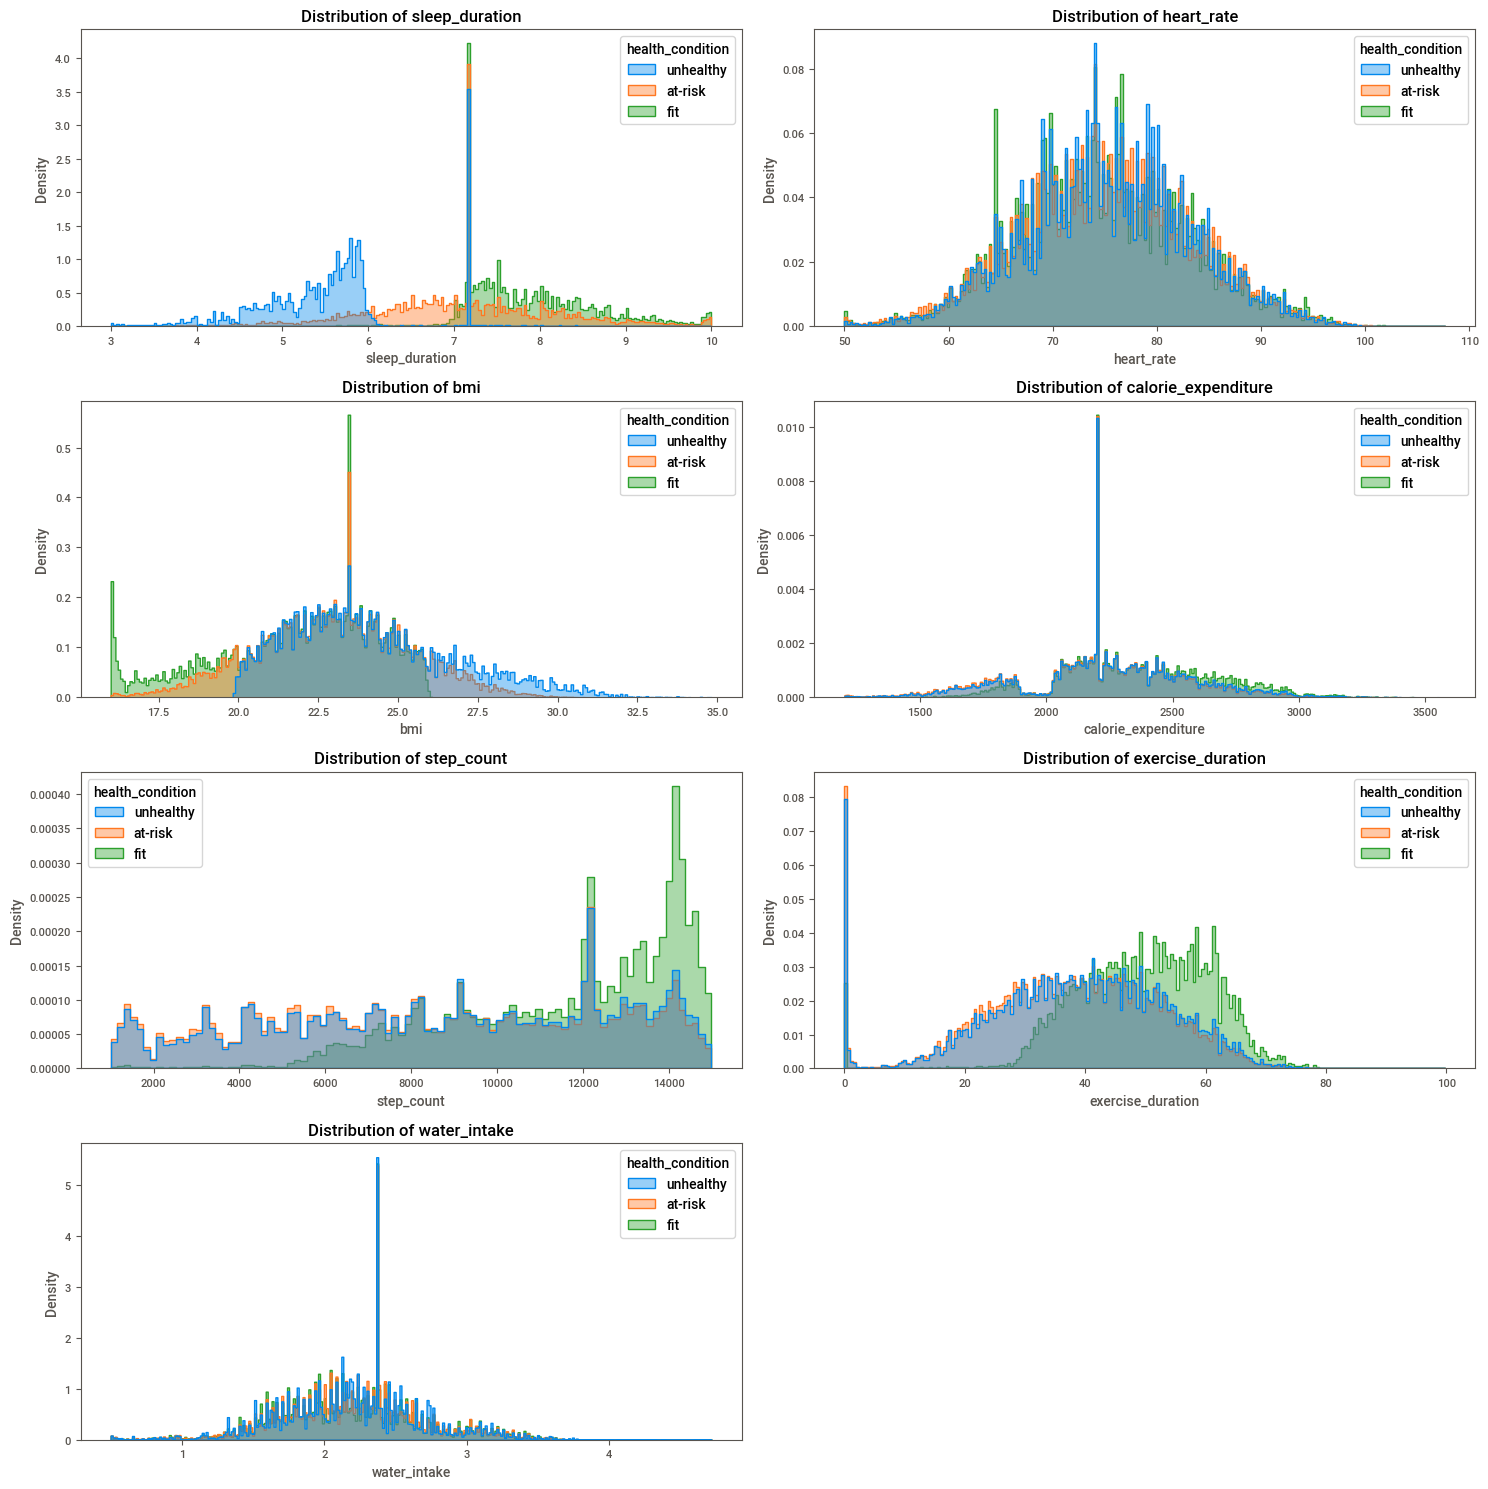

In [50]:
# Plot continues data
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(4, 2, figsize=(15, 15))  #figures fig are the entire canvas. Ax are a single plot
axes = axes.flatten()  # axes is numpy array

cont_var = ['sleep_duration', 'heart_rate','bmi','calorie_expenditure','step_count',
            'exercise_duration','water_intake']

for i, x in enumerate(cont_var):
    sns.histplot(data=train_df, x=x, hue='health_condition',
                 stat='density',         
                 common_norm=False,      
                 element='step',      
                 alpha=0.4,
                 ax=axes[i])
    axes[i].set_title(f'Distribution of {x}')

axes[-1].remove()
plt.tight_layout()
plt.show()

As we can see from the above distribution diagrams sleep duration 

# Preprocess the data.

I will use ordinal encoding on the categorical data to convert the words into numbers.

Then i will use min-max scaling to convert each continuous feature in the range 0 and 1.

In [30]:
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_var = ['health_condition','stress_level','sleep_quality',
           'physical_activity_level','smoking_alcohol','gender']

cont_var = ['sleep_duration', 'heart_rate','bmi','calorie_expenditure','step_count',
            'exercise_duration','water_intake']

cat_pipeline = Pipeline([
    ('ord_enc',OrdinalEncoder())
])

num_pipeline = Pipeline([
    ('std_scaler',MinMaxScaler())
])

full_pipeline = ColumnTransformer([
    ("cat", cat_pipeline,cat_var),
    ('num',num_pipeline,cont_var),
])
full_pipeline.set_output(transform="pandas")
# Apply the column transformer  
train_df_prepared = full_pipeline.fit_transform(train_df)

In [13]:
train_df_prepared

,cat__health_condition,cat__stress_level,cat__sleep_quality,cat__physical_activity_level,cat__smoking_alcohol,cat__gender,num__sleep_duration,num__heart_rate,num__bmi,num__calorie_expenditure,num__step_count,num__exercise_duration,num__water_intake
0,2.0,0.0,0.0,2.0,2.0,0.0,0.317143,0.357019,0.513284,0.409244,0.023148,0.198397,0.322275
1,0.0,1.0,0.0,1.0,2.0,2.0,0.361429,0.369151,0.522848,0.321849,0.635065,0.500000,0.180095
2,2.0,0.0,2.0,0.0,2.0,1.0,0.327143,0.440208,0.453773,0.625210,0.944059,0.381764,0.260664
3,2.0,0.0,0.0,0.0,1.0,0.0,0.242857,0.471404,0.378852,0.600840,0.440952,0.600200,0.360190
4,0.0,2.0,0.0,2.0,2.0,1.0,0.604286,0.405546,0.660999,0.571429,0.398800,0.460922,0.414692
...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,0.0,0.0,2.0,0.0,2.0,0.0,0.472857,0.341421,0.430925,0.402101,0.798743,0.308617,0.592417
690084,0.0,2.0,0.0,1.0,0.0,1.0,0.397143,0.069324,0.550478,0.696639,0.391941,0.525050,0.227488
690085,1.0,2.0,0.0,0.0,0.0,1.0,0.662857,0.618718,0.314028,0.418067,0.588626,0.413828,0.253555
690086,0.0,2.0,0.0,0.0,2.0,1.0,0.534286,0.398614,0.145058,0.361765,0.883332,0.567134,0.497630


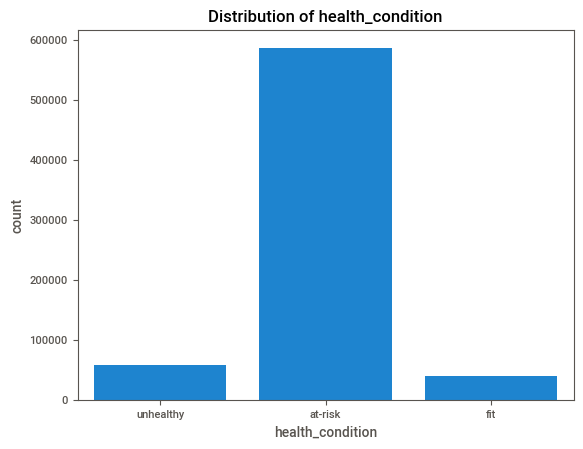

In [14]:
import seaborn as sns

fig, ax = plt.subplots()
sns.countplot(data=train_df, x="health_condition", ax=ax)
ax.set_title("Distribution of health_condition")
plt.show()

As we can see from the above barplot the data are highly imbalanced since the 0 category (at risk) <br> 
is the most common category with over 80% of the whole data. <br>

# Plot correlation

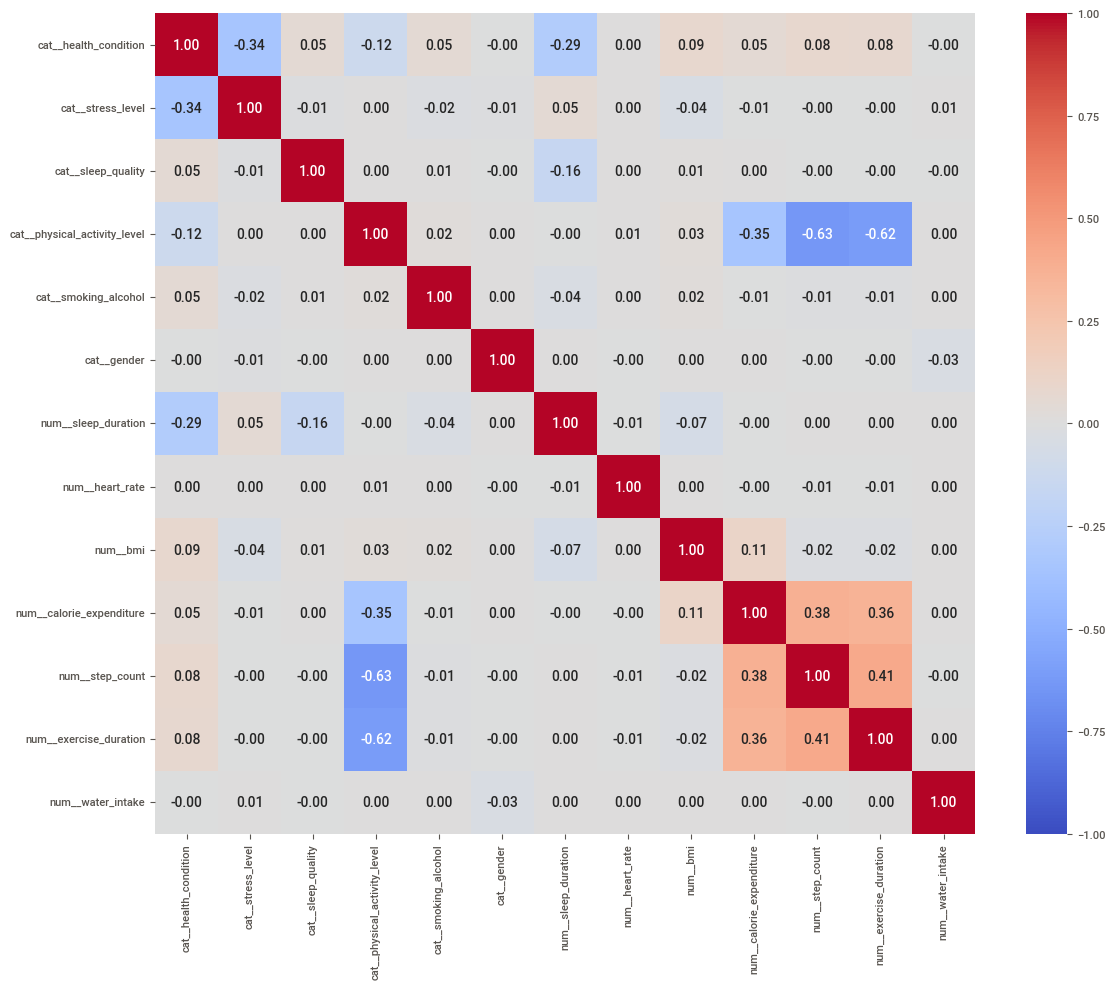

In [15]:
plt.figure(figsize=(12, 10))
ax = sns.heatmap(train_df_prepared.corr(), annot=True, fmt=".2f", cmap="coolwarm",
                 vmin=-1, vmax=1)
plt.tight_layout()

# Modeling

Submissions are scored using balanced accuracy, which compares the predicted class against the true target. <br>
As i ve already mention we 've got class imbalance on the data and in order to confront this problem i will use <br>
StratifiedKFold.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

# dependent variable
y = train_df_prepared['cat__health_condition']

# Independent variables 
X = train_df_prepared.drop('cat__health_condition', axis=1)

# Define the stratified K fold
num_folds = 5
shuffle = True
random_seed = 42

cv_strategy = StratifiedKFold(
    n_splits=num_folds, 
    shuffle=shuffle, 
    random_state=random_seed,
)

folds = list(cv_strategy.split(
    X, y, groups=None,
))

# Models that i will loop for training data
svc = SVC()
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier()
lrc = LogisticRegression()
rfc = RandomForestClassifier()
abc = AdaBoostClassifier()
bc = BaggingClassifier()
etc = ExtraTreesClassifier()
gbdt = GradientBoostingClassifier()
xgb = XGBClassifier()


clfs = {
    # 'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'Bgc': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb,
}
#Let s just make a dictionary in order to organize all of the ML classification algorithms
# param_grids = {
#     # 'SVC':      {'C': [1, 10], 'kernel': ['rbf']},
#     'KN':       {'n_neighbors': [5, 11]},
#     'NB':       {'alpha': [0.5, 1.0]},
#     'DT':       {'max_depth': [5, 10]},
#     'LR':       {'C': [0.1, 1], 'max_iter': [1000]},
#     'RF':       {'n_estimators': [100], 'max_depth': [10, None]},
#     'AdaBoost': {'n_estimators': [50, 100]},
#     'Bgc':      {'n_estimators': [10, 50]},
#     'ETC':      {'n_estimators': [100], 'max_depth': [10, None]},
#     'GBDT':     {'n_estimators': [100], 'learning_rate': [0.1], 'max_depth': [3]},
#     'xgb':      {'n_estimators': [100], 'learning_rate': [0.1], 'max_depth': [3, 6]},
# }

results = {}

In [17]:
from sklearn.model_selection import cross_val_score
for name, clf in clfs.items():
    print(f"Evaluating {name}")
    scores = cross_val_score(
        clf, X, y,
        cv=cv_strategy,
        scoring='balanced_accuracy',
        n_jobs=-1,
    )
    results[name] = {
        'mean_score': scores.mean(),
        'std_score': scores.std(),
    }
    print(f"  {name}: {scores.mean():.4f} ± {scores.std():.4f}")

summary = pd.DataFrame(results).T.sort_values('mean_score', ascending=False)
print(summary)

Evaluating KN
  KN: 0.7998 ± 0.0007
Evaluating NB
  NB: 0.3333 ± 0.0000
Evaluating DT
  DT: 0.8507 ± 0.0020
Evaluating LR
  LR: 0.5908 ± 0.0011
Evaluating RF
  RF: 0.8535 ± 0.0016
Evaluating AdaBoost
  AdaBoost: 0.5806 ± 0.0012
Evaluating Bgc
  Bgc: 0.8509 ± 0.0011
Evaluating ETC


/home/charis/Desktop/Projects/Predict Student Health Risk/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  ETC: 0.8482 ± 0.0010
Evaluating GBDT
  GBDT: 0.8536 ± 0.0015
Evaluating xgb
  xgb: 0.8590 ± 0.0014
          mean_score  std_score
xgb         0.859038   0.001353
GBDT        0.853610   0.001453
RF          0.853499   0.001556
Bgc         0.850857   0.001078
DT          0.850695   0.001981
ETC         0.848155   0.001004
KN          0.799792   0.000730
LR          0.590847   0.001106
AdaBoost    0.580637   0.001215
NB          0.333333   0.000000


In [23]:
test_df.shape

(295753, 14)

In [38]:
test_df.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [39]:
test_df.isnull().sum()

id                             0
sleep_duration             32571
heart_rate                  3357
bmi                         5956
calorie_expenditure        22652
step_count                  5964
exercise_duration           2958
water_intake               18633
diet_type                   2958
stress_level               35490
sleep_quality              24999
physical_activity_level    15695
smoking_alcohol            12249
gender                      9160
dtype: int64

In [ ]:
from sklearn.impute import SimpleImputer

cat_var = ['stress_level','sleep_quality','physical_activity_level',
           'smoking_alcohol','gender']               
cont_var = ['sleep_duration','heart_rate','bmi','calorie_expenditure',
            'step_count','exercise_duration','water_intake']

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  
    ('ord_enc', OrdinalEncoder()),
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),      
    ('minmax_scaler', MinMaxScaler()),
])

full_pipeline = ColumnTransformer([
    ("cat", cat_pipeline, cat_var),
    ("num", num_pipeline, cont_var),
])
full_pipeline.set_output(transform="pandas")


y = train_df['health_condition']
X_raw = train_df.drop(columns=['health_condition'])

X = full_pipeline.fit_transform(X_raw)
X_test = full_pipeline.transform(test_df)

dt_clf = DecisionTreeClassifier()
dt_clf.fit(X, y)
y_pred = dt_clf.predict(X_test)

submission = pd.DataFrame({'id': test_df['id'], 'health_condition': y_pred})
submission.to_csv('submission.csv', index=False)
submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [28]:
# Αν το y ήταν encoded με LabelEncoder, γύρνα τις προβλέψεις σε labels
# y_pred_labels = le.inverse_transform(y_pred)
# Αν το y ήταν raw strings (π.χ. train_df['health_condition']), το y_pred είναι ήδη labels:
y_pred_labels = y_pred

submission = pd.DataFrame({
    'id': test_df['id'],
    'health_condition': y_pred_labels,
})

submission.to_csv('submission.csv', index=False)
print(submission.head())
print(submission.shape)   # πρέπει να έχει τόσες γραμμές όσες το test_df

       id  health_condition
0  690088               2.0
1  690089               0.0
2  690090               0.0
3  690091               0.0
4  690092               2.0
(295753, 2)
